# Three MSI modalities: original-space feature plots

Companion figures notebook to `examples/three_msi_modalities_visium_hd.ipynb`: loads each of
the three MSI modalities (metabolomics, lipidomics negative, lipidomics positive) on its own
-- no alignment, no Visium, no H&E images -- and plots one feature per modality directly in
the instrument's own raw, unaligned coordinate system (same "original coordinates" style used
earlier for the single-modality classic-Visium notebook), each with its own colormap.

In [1]:
import sys
sys.path.insert(0, "msi")  # examples/msi/ contains msi_loader.py (MSI vendor CSV parsing)

import numpy as np
import matplotlib.pyplot as plt

from msi_loader import MSIdata

## Modality config

Same CSV exports as `examples/three_msi_modalities_visium_hd.ipynb`, plus one feature and
colormap to plot per modality -- swap in any other column from that modality's own feature
table.

In [4]:
alix_base = "/home/croizer/Downloads/transfer_544950_files_937b8558"

modalities = {
    "metabo": {
        "intensity": f"{alix_base}/Results-Metabolomics/Statistic files/1974/Regions-Root Mean Square.csv",
        "annotation": f"{alix_base}/Results-Metabolomics/Library/Metabolomics.csv",
        "region": f"{alix_base}/Results-Metabolomics/Statistic files/1974/20260205_Brosch_Metab1974.csv",
        "feature": "Glucose phosphate / Fructose phosphate*",
        "cmap": "PiYG",
    },
    "lipidneg": {
        "intensity": f"{alix_base}/Results-Lipidomics Negative/Statistic files/1974/Regions-Total Ion Count.csv",
        "annotation": f"{alix_base}/Results-Lipidomics Negative/Library/Lipidomics Negative.csv",
        "region": f"{alix_base}/Results-Lipidomics Negative/Statistic files/1974/20260206_Brosch_Lip_Neg_1974.csv",
        "feature": "LPE 18:1",
        "cmap": "BrBG",
    },
    "lipidpos": {
        "intensity": f"{alix_base}/Results-Lipidomics-Positive/Statistic files/1974/Regions-Total Ion Count.csv",
        "annotation": f"{alix_base}/Results-Lipidomics-Positive/Library/Lipidmics positive.csv",
        "region": f"{alix_base}/Results-Lipidomics-Positive/Statistic files/1974/20260209_Brosch_Lip_Pos1974.csv",
        "feature": "CAR 18:1",
        "cmap": "PRGn",
    },
}

vmin_percentile = 1
vmax_percentile = 99

## One plot per modality, in its own original coordinates

No image underlay here -- these raw coordinates are each in that instrument's own arbitrary
coordinate system, not yet aligned to anything (that's what `align_grid` does in the other
notebook). `invert_yaxis()` just matches the image-style top-left origin convention used
elsewhere in this pipeline.

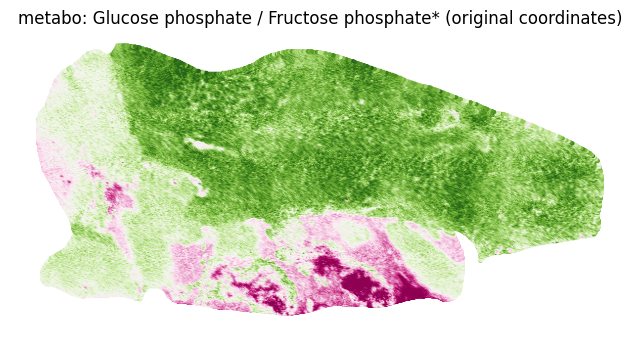

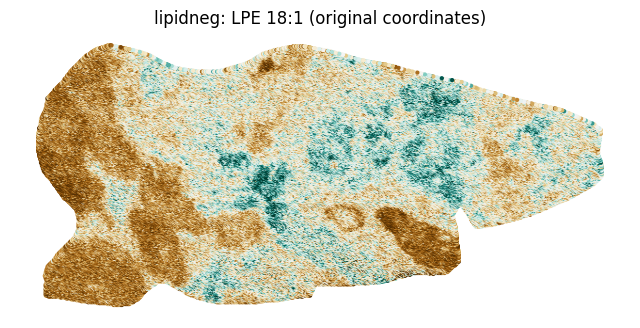

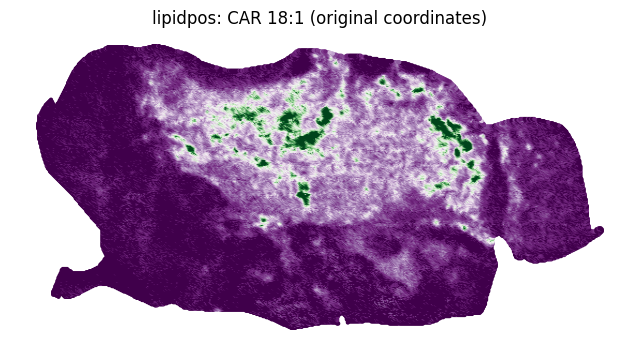

In [5]:
for name, cfg in modalities.items():
    msi = MSIdata(cfg["intensity"], cfg["annotation"], cfg["region"])
    counts = msi.get_count_formated()
    points_xy = msi.coordinates[["x", "y"]].values.astype(float)
    values = counts[cfg["feature"]].values.astype(float)

    vmin, vmax = np.nanpercentile(values, [vmin_percentile, vmax_percentile])

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(points_xy[:, 0], points_xy[:, 1], c=values, cmap=cfg["cmap"], vmin=vmin, vmax=vmax, s=4)
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.axis("off")
    #ax.set_title(f"{name}: {cfg['feature']} (original coordinates)")
    plt.show()